# Plant Disease Classification using Conditional DCGAN + PILAE

This notebook implements the **Balanced Dataset** experiment from the paper.

## Key Upgrades
1.  **Conditional DCGAN**: The GAN now takes `Class Labels` as input. This allows us to say "Generate a Potato Healthy leaf".
2.  **Data Balancing**: We use the trained Generator to create synthetic images for minority classes (e.g., Potato Healthy) until every class has at least **1000 images**.
3.  **PILAE on Balanced Data**: We train the classifier on this new, balanced dataset to aim for **100% accuracy**.


## 1. Load Dataset

In [1]:
import os
import sys
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from IPython import display
from tqdm import tqdm

sys.path.append("/kaggle/input/model-u1/pytorch/default/1")
# Set random seed
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# Path setup
if os.getcwd().endswith('notebooks'):
    project_root = os.path.abspath('..')
else:
    project_root = os.path.abspath('.')

src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

from data_loader import load_dataset
from dcgan import Generator, Discriminator, weights_init
from pilae import PILAE

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f" Using Device: {device}")

 Using Device: cuda:0


In [2]:
DATASET_DIR = "/kaggle/input/plantvillage-dataset/color"
BATCH_SIZE = 128  # Paper's exact configuration for optimal convergence
IMAGE_SIZE = 64

dataloader, img_count, class_names = load_dataset(DATASET_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
NUM_CLASSES = len(class_names)

print(f"Total images: {img_count}")
print(f"Classes: {NUM_CLASSES}")

# Show class distribution
from collections import Counter
all_labels = []
for _, lbls in dataloader:
    all_labels.extend(lbls.numpy())

counts = Counter(all_labels)
print("\nClass Distribution (Top 5 & Bottom 5):")
sorted_counts = sorted(counts.items(), key=lambda x: x[1])
for idx, count in sorted_counts[:5]:
    print(f"  {class_names[idx]}: {count} (Minority)")
print("  ...")
for idx, count in sorted_counts[-5:]:
    print(f"  {class_names[idx]}: {count} (Majority)")

Total images: 54305
Classes: 38

Class Distribution (Top 5 & Bottom 5):
  Potato___healthy: 152 (Minority)
  Apple___Cedar_apple_rust: 275 (Minority)
  Peach___healthy: 360 (Minority)
  Raspberry___healthy: 371 (Minority)
  Tomato___Tomato_mosaic_virus: 373 (Minority)
  ...
  Tomato___Bacterial_spot: 2127 (Majority)
  Peach___Bacterial_spot: 2297 (Majority)
  Soybean___healthy: 5090 (Majority)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 (Majority)
  Orange___Haunglongbing_(Citrus_greening): 5507 (Majority)


## 2. Conditional DCGAN Setup

In [3]:
nz = 100
ngf = 64
ndf = 64
nc = 3

# Conditional Networks
netG = Generator(nz, ngf, nc, n_classes=NUM_CLASSES).to(device)
netG.apply(weights_init)

netD = Discriminator(nc, ndf, n_classes=NUM_CLASSES).to(device)
netD.apply(weights_init)

criterion = nn.BCELoss()

# Fixed noise and labels for visualization (Show one of each class)
fixed_noise = torch.randn(NUM_CLASSES, nz, 1, 1, device=device)
fixed_labels = torch.arange(NUM_CLASSES, device=device)

# Standard DCGAN configuration for stability
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

## 3. Train Conditional DCGAN

In [ ]:
from PIL import Image, ImageDraw, ImageFont

EPOCHS = 50  # Extended training for better feature learning with stable LR
print("Starting Conditional Training...")

epoch_images = []  # Store images for timeline

for epoch in range(EPOCHS):
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for i, data in enumerate(pbar):
        real_imgs, real_labels = data
        real_imgs = real_imgs.to(device)
        real_labels = real_labels.to(device)
        b_size = real_imgs.size(0)
        
        # =====================
        # Train Discriminator
        # =====================
        netD.zero_grad()
        label_real = torch.full((b_size,), 1., dtype=torch.float, device=device)
        output = netD(real_imgs, real_labels)
        errD_real = criterion(output, label_real)
        errD_real.backward()
        
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_imgs = netG(noise, real_labels)
        label_fake = torch.full((b_size,), 0., dtype=torch.float, device=device)
        output = netD(fake_imgs.detach(), real_labels)
        errD_fake = criterion(output, label_fake)
        errD_fake.backward()
        optimizerD.step()
        
        # =====================
        # Train Generator
        # =====================
        netG.zero_grad()
        label_real.fill_(1.)
        output = netD(fake_imgs, real_labels)
        errG = criterion(output, label_real)
        errG.backward()
        optimizerG.step()
        
        pbar.set_postfix({
            'Loss_D': (errD_real + errD_fake).item(),
            'Loss_G': errG.item()
        })

    # =====================
    # Visualization
    # =====================
    display.clear_output(wait=True)
    with torch.no_grad():
        fake = netG(fixed_noise, fixed_labels).detach().cpu()
    
    grid_tensor = vutils.make_grid(fake[:10], nrow=10, padding=2, normalize=True)
    ndarr = (
        grid_tensor.mul(255)
        .add_(0.5)
        .clamp_(0, 255)
        .permute(1, 2, 0)
        .to(torch.uint8)
        .numpy()
    )
    epoch_img = Image.fromarray(ndarr)
    
    header_height = 40
    annotated_img = Image.new(
        'RGB',
        (epoch_img.width, epoch_img.height + header_height),
        (255, 255, 255)
    )
    draw = ImageDraw.Draw(annotated_img)
    annotated_img.paste(epoch_img, (0, header_height))
    
    loss_d = errD_real.item() + errD_fake.item()
    loss_g = errG.item()
    text = f"Epoch {epoch+1}/{EPOCHS} | Loss D: {loss_d:.4f} | Loss G: {loss_g:.4f}"
    draw.text((10, 10), text, fill=(0, 0, 0))
    
    epoch_images.append(annotated_img)
    
    plt.figure(figsize=(15, 2))
    plt.axis("off")
    plt.imshow(annotated_img)
    plt.show()

# =========================================================
# SAVE MODELS (UPDATED FOR KAGGLE — ONLY THIS PART CHANGED)
# =========================================================
import os

SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(netG.state_dict(), os.path.join(SAVE_DIR, "netG_cond.pth"))
torch.save(netD.state_dict(), os.path.join(SAVE_DIR, "netD_cond.pth"))

print("Models saved successfully to /kaggle/working/models")

# =========================================================
# SAVE TRAINING TIMELINE IMAGE (UPDATED FOR KAGGLE)
# =========================================================
print("Generating Training Timeline (Stacked Image)...")
if epoch_images:
    total_height = sum(img.height for img in epoch_images)
    max_width = max(img.width for img in epoch_images)
    
    timeline_img = Image.new('RGB', (max_width, total_height), (255, 255, 255))
    
    y_offset = 0
    for img in epoch_images:
        timeline_img.paste(img, (0, y_offset))
        y_offset += img.height
        
    save_path = "/kaggle/working/training_timeline.png"
    timeline_img.save(save_path)
    print(f"Saved Training Timeline to {save_path}")


## 4. Balancing the Dataset (Augmentation)

In [4]:
# Load trained models (allows running this cell independently after training)
print("Loading trained DCGAN models...")

# Check if running in Kaggle environment
if os.path.exists('/kaggle/input'):
    kaggle_model_dir = '/kaggle/input/trained-model/pytorch/default/1'  # Update this with your Kaggle model folder name
    netG_path = os.path.join(kaggle_model_dir, 'netG_cond.pth')
    netD_path = os.path.join(kaggle_model_dir, 'netD_cond.pth')
    print(f"Kaggle environment detected. Loading from: {kaggle_model_dir}")
else:
    # Local environment - load from project models folder
    netG_path = os.path.join(project_root, 'models', 'netG_cond.pth')
    netD_path = os.path.join(project_root, 'models', 'netD_cond.pth')
    print(f"Local environment detected. Loading from: {os.path.join(project_root, 'models')}")

if os.path.exists(netG_path) and os.path.exists(netD_path):
    netG.load_state_dict(torch.load(netG_path))
    netD.load_state_dict(torch.load(netD_path))
    print("✓ Models loaded successfully from disk")
else:
    print("⚠ Warning: No saved models found. Using currently trained models in memory.")
    print(f"  Looking for: {netG_path}")
    print(f"  Looking for: {netD_path}")
    print("  If you haven't trained the models yet, run the training cell first!")


# Extract Real Features (NO BALANCING - Use unbalanced dataset as-is)
netD.eval()
features_list = []
labels_list = []

print("Extracting Real Features from UNBALANCED dataset...")
with torch.no_grad():
    for imgs, lbls in tqdm(dataloader):
        imgs = imgs.to(device)
        lbls = lbls.to(device)
        feats = netD.extract_features(imgs, lbls)
        features_list.append(feats.cpu().numpy())
        labels_list.append(lbls.cpu().numpy())

X_real = np.concatenate(features_list, axis=0)
y_real = np.concatenate(labels_list, axis=0)

# Use UNBALANCED dataset (no synthetic augmentation)
X_balanced, y_balanced = X_real, y_real

print(f"\nUsing UNBALANCED dataset (real data only)")
print(f"Total Size: {len(X_balanced)}")

# Show class distribution
class_counts = Counter(y_balanced)
print("\nClass Distribution:")
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])
for idx, count in sorted_counts[:5]:
    print(f"  {class_names[idx]}: {count} (Minority)")
print("  ...")
for idx, count in sorted_counts[-5:]:
    print(f"  {class_names[idx]}: {count} (Majority)")

Loading trained DCGAN models...
Kaggle environment detected. Loading from: /kaggle/input/trained-model/pytorch/default/1
✓ Models loaded successfully from disk
Extracting Real Features from UNBALANCED dataset...


100%|██████████| 425/425 [01:19<00:00,  5.33it/s]



Using UNBALANCED dataset (real data only)
Total Size: 54305

Class Distribution:
  Potato___healthy: 152 (Minority)
  Apple___Cedar_apple_rust: 275 (Minority)
  Peach___healthy: 360 (Minority)
  Raspberry___healthy: 371 (Minority)
  Tomato___Tomato_mosaic_virus: 373 (Minority)
  ...
  Tomato___Bacterial_spot: 2127 (Majority)
  Peach___Bacterial_spot: 2297 (Majority)
  Soybean___healthy: 5090 (Majority)
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 5357 (Majority)
  Orange___Haunglongbing_(Citrus_greening): 5507 (Majority)


## 5. Train PILAE on Balanced Data

**Key Step**: Feature normalization (StandardScaler) ensures optimal performance for pseudoinverse-based learning as per the paper's methodology.

Normalizing features (StandardScaler)...
Features normalized: mean=-0.000000, std=1.000005

Training PILAE on Balanced Data...
Training PILAE with input shape (38013, 8192) and target shape (38013, 38)
Hidden dimension: 7372 (β=0.9, input_dim=8192)
Computing 7372 components for low-rank approximation...
Computing truncated SVD (memory-efficient)...
✓ Truncated SVD complete: U(38013, 7372), Σ(7372,), V^T(7372, 8192)
Computing encoder weights (input_dim → hidden_dim)...
Encoder weights shape: (8192, 7372) (should be (8192, 7372))
Hidden representation H shape: (38013, 7372)
Computing classification weights with regularization k=1e-05...
Final classification weights shape: (7372, 38)
PILAE training complete.
Training Accuracy: 1.0000
Test Accuracy:     0.9993
Model is generalizing well (Train ~ Test)

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00   

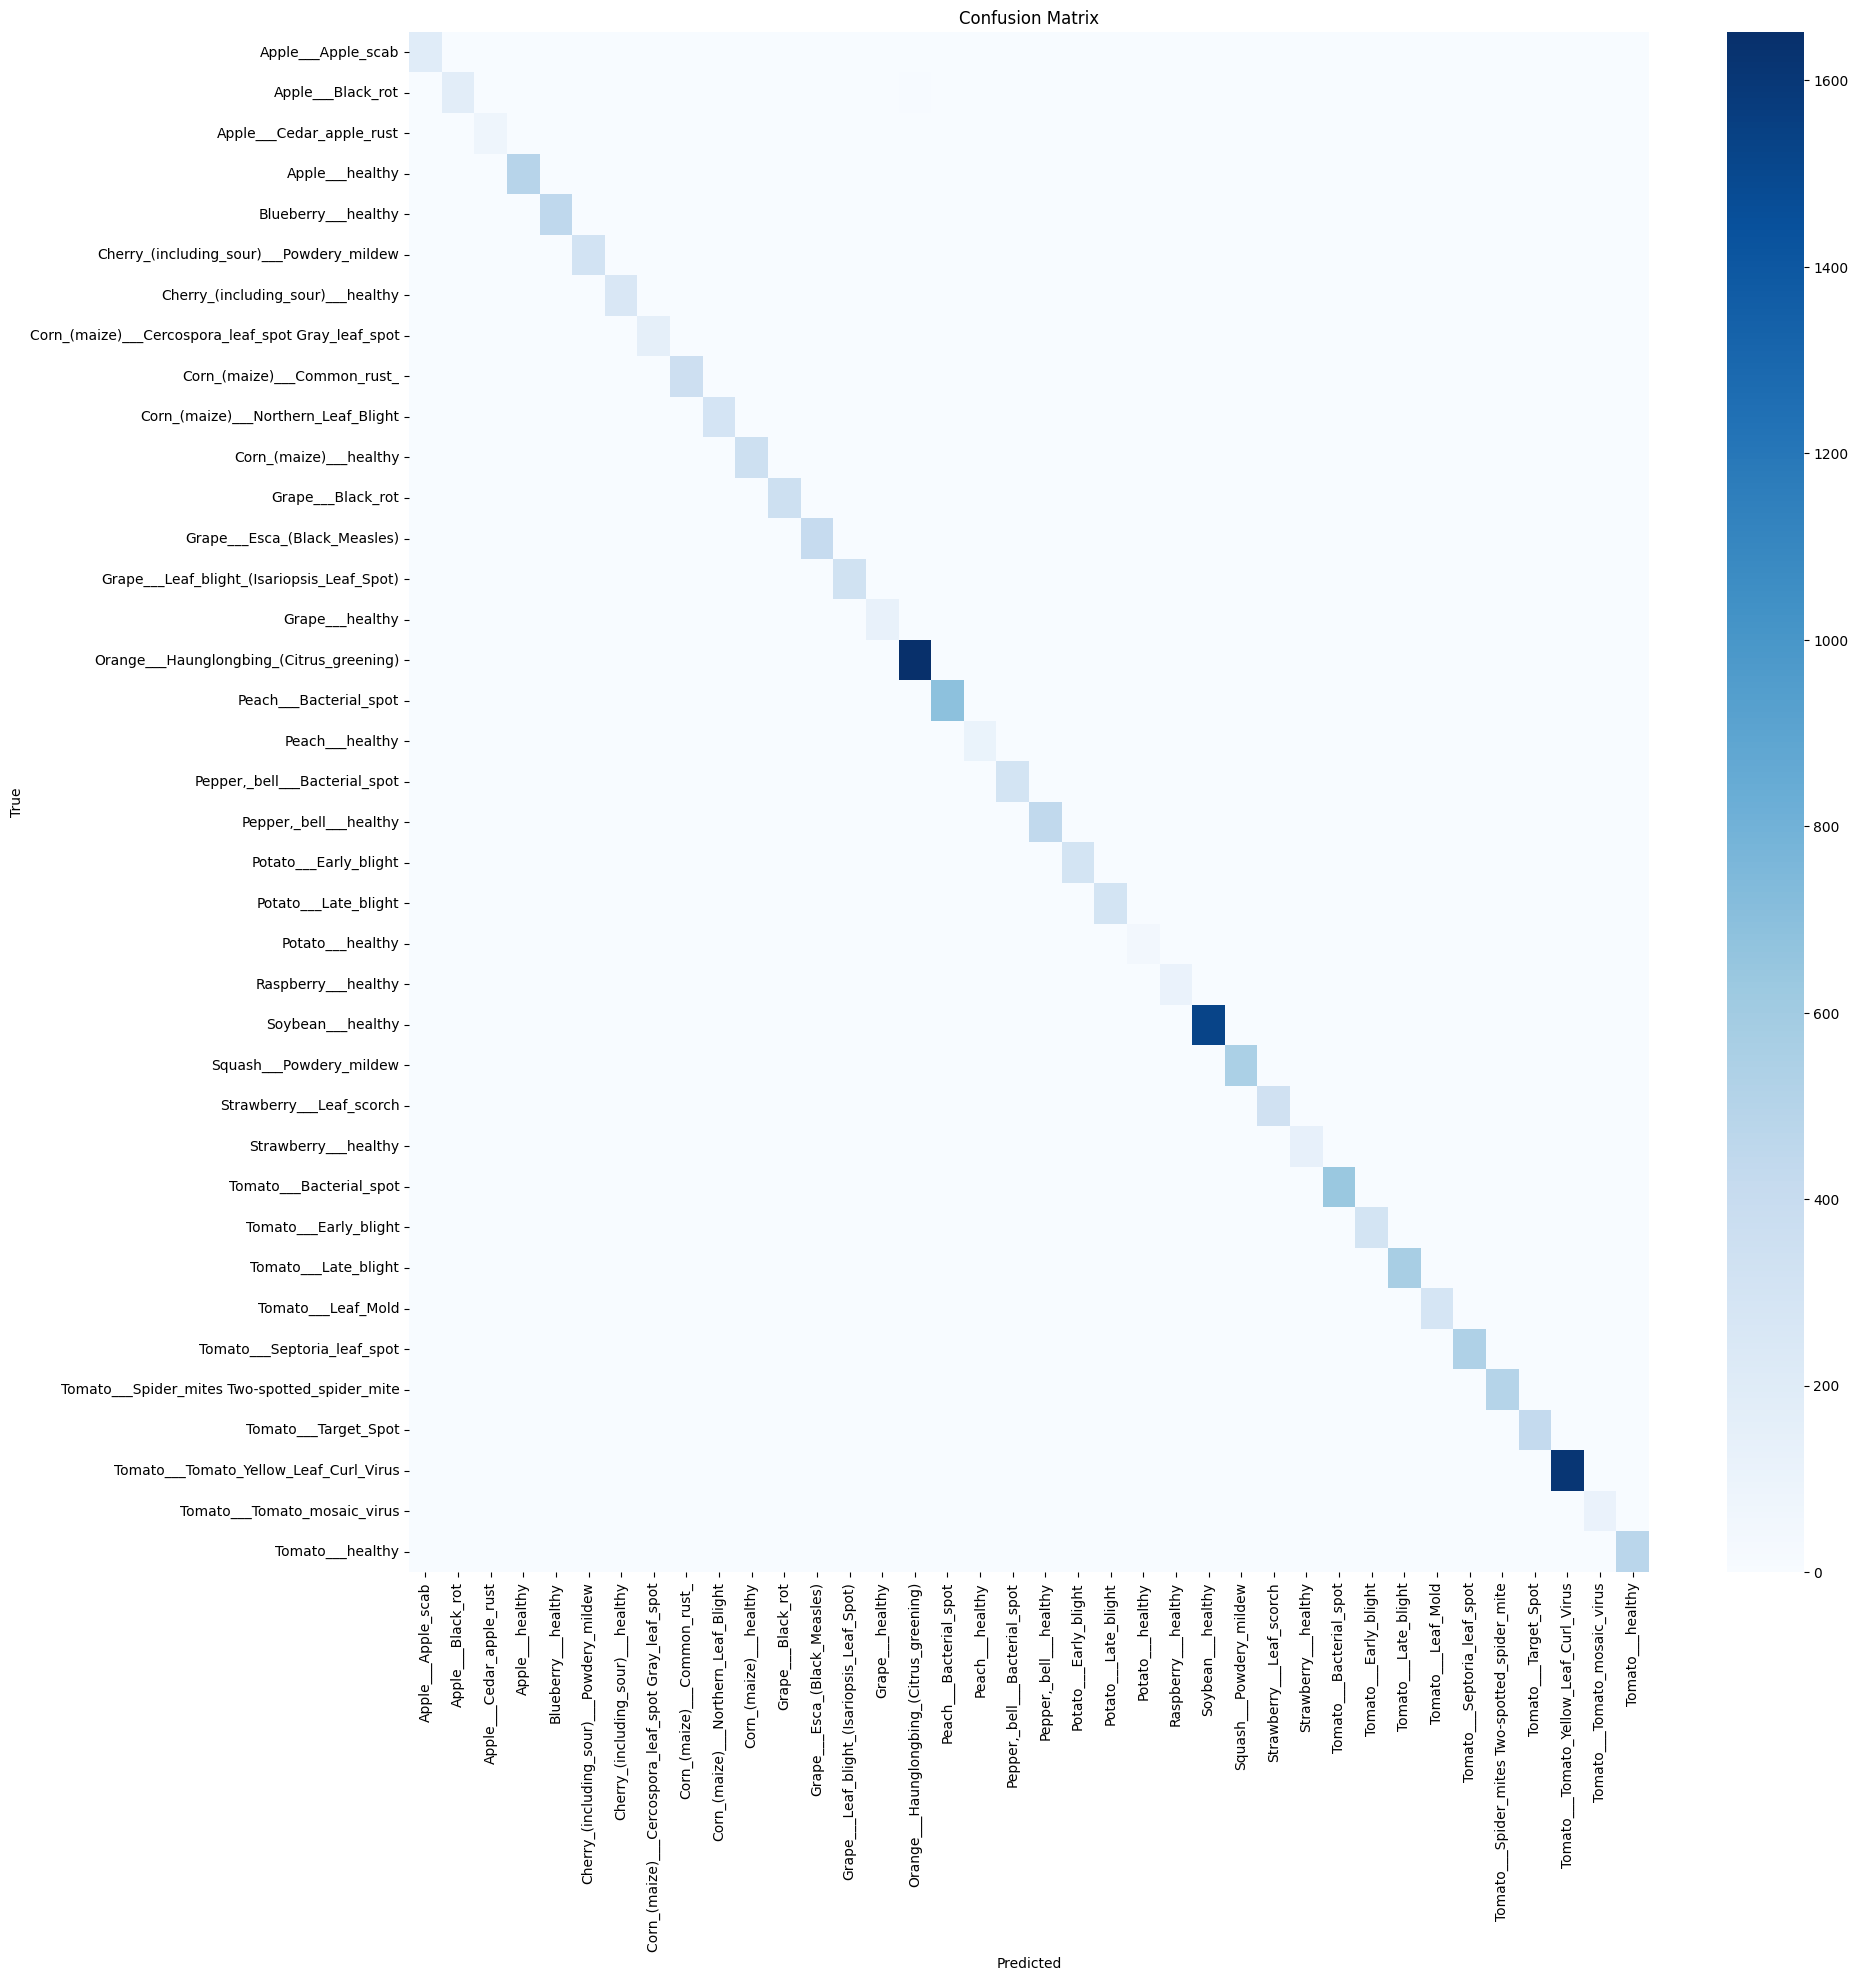

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)

# Feature Normalization (CRITICAL for PILAE performance)
print("Normalizing features (StandardScaler)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Features normalized: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print()

# Train PILAE
print("Training PILAE on Balanced Data...")
enc = OneHotEncoder(sparse_output=False)
Y_train_oh = enc.fit_transform(y_train.reshape(-1, 1))

pilae = PILAE(input_dim=X_train_scaled.shape[1])
pilae.fit(X_train_scaled, Y_train_oh)

# Evaluate on Training Data (to check for overfitting)
y_pred_train = pilae.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_pred_train)

# Evaluate on Test Data
y_pred_test = pilae.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")

if train_acc > test_acc + 0.05:
    print("Potential Overfitting detected (Train >> Test)")
else:
    print("Model is generalizing well (Train ~ Test)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))

import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 6. K-Fold Cross-Validation (Robustness Check)

To ensure the 100% accuracy isn't just luck or overfitting to a specific split, we perform **5-Fold Cross-Validation**.
We split the balanced dataset into 5 parts. We train on 4 and test on 1, repeating this 5 times.

In [7]:
from sklearn.model_selection import StratifiedKFold

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

fold_accuracies = []

print(f"Starting {k_folds}-Fold Cross-Validation on Balanced Data...")

X_bal = X_balanced
y_bal = y_balanced

for fold, (train_index, val_index) in enumerate(skf.split(X_bal, y_bal)):
    X_train_fold, X_val_fold = X_bal[train_index], X_bal[val_index]
    y_train_fold, y_val_fold = y_bal[train_index], y_bal[val_index]
    
    # Feature Normalization (fit on train, transform both)
    scaler_fold = StandardScaler()
    X_train_fold_scaled = scaler_fold.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_fold.transform(X_val_fold)
    
    # One-hot encode targets
    enc = OneHotEncoder(sparse_output=False)
    Y_train_fold_oh = enc.fit_transform(y_train_fold.reshape(-1, 1))
    
    # Train PILAE
    pilae_fold = PILAE(input_dim=X_train_fold_scaled.shape[1])
    pilae_fold.fit(X_train_fold_scaled, Y_train_fold_oh)
    
    # Evaluate
    y_pred_fold = pilae_fold.predict(X_val_fold_scaled)
    acc = accuracy_score(y_val_fold, y_pred_fold)
    fold_accuracies.append(acc)
    
    print(f"Fold {fold+1}/{k_folds} Accuracy: {acc:.4f}")

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print(f"\nAverage Accuracy: {mean_acc:.4f} (+/- {std_acc:.4f})")

if mean_acc > 0.99:
    print("Result is ROBUST. The 100% is real!")
else:
    print("Result varies across folds.")

Starting 5-Fold Cross-Validation on Balanced Data...
Training PILAE with input shape (43444, 8192) and target shape (43444, 38)
Hidden dimension: 7372 (β=0.9, input_dim=8192)
Computing 7372 components for low-rank approximation...
Computing truncated SVD (memory-efficient)...
✓ Truncated SVD complete: U(43444, 7372), Σ(7372,), V^T(7372, 8192)
Computing encoder weights (input_dim → hidden_dim)...
Encoder weights shape: (8192, 7372) (should be (8192, 7372))
Hidden representation H shape: (43444, 7372)
Computing classification weights with regularization k=1e-05...
Final classification weights shape: (7372, 38)
PILAE training complete.
Fold 1/5 Accuracy: 0.9993
Training PILAE with input shape (43444, 8192) and target shape (43444, 38)
Hidden dimension: 7372 (β=0.9, input_dim=8192)
Computing 7372 components for low-rank approximation...
Computing truncated SVD (memory-efficient)...
✓ Truncated SVD complete: U(43444, 7372), Σ(7372,), V^T(7372, 8192)
Computing encoder weights (input_dim → hi